In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate
import scipy.stats as stats

import warnings

In [7]:
df = pd.read_csv("/Users/elifakar/Downloads/archive/car data.csv")
df.head(5) #first 5 lines

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.tail() # last 5 lines

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [9]:
df.shape #We examined the dataset size to determine the number of observations and features, and to assess whether it is sufficient for training a reliable model.


(301, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
df = df.dropna()
df.shape

(301, 9)

<Axes: >

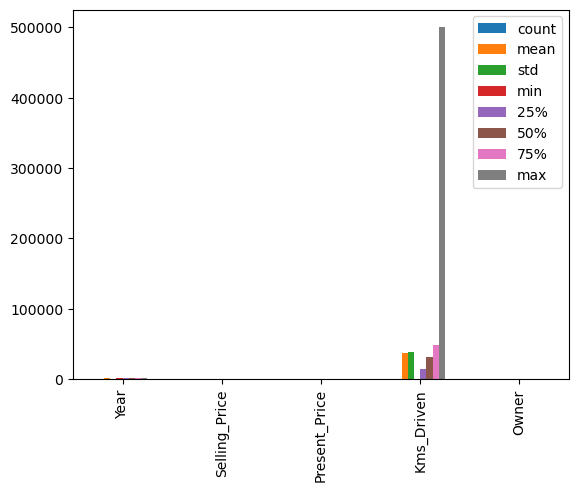

In [12]:
df.describe().T.plot(kind='bar')  # We created visualizations to better understand the data from a graphical perspective. This allows us to identify relative magnitudes across variables and detect any potential imbalances in the dataset.


In [13]:
df.columns.to_list() #We examined the columns to understand which features are available and to determine which ones should be selected for use in the model.


['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

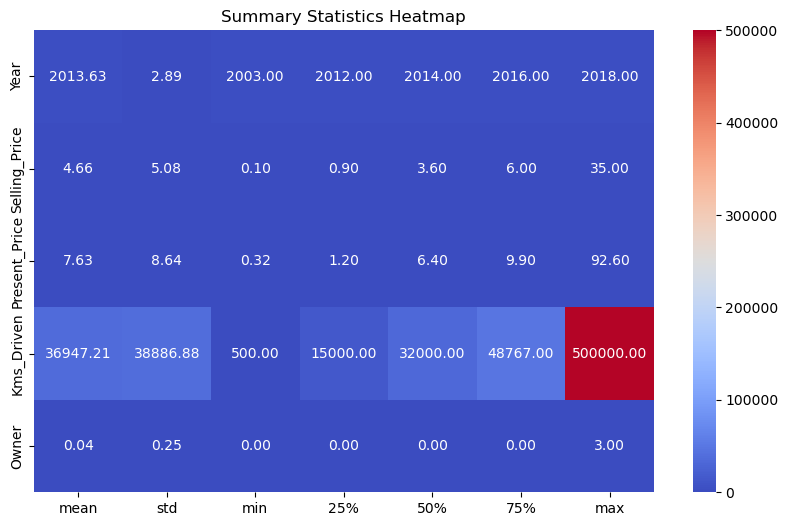

In [14]:
desc = df.describe().T 
plt.figure(figsize=(10, 6)) 
sns.heatmap(desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']], annot=True, cmap='coolwarm', fmt='.2f', cbar=True) 
plt.title('Summary Statistics Heatmap') 
plt.show()

In [15]:
# As observed, the “kms driven” feature has significantly larger values, indicating that the data is imbalanced; therefore, feature scaling will be required.


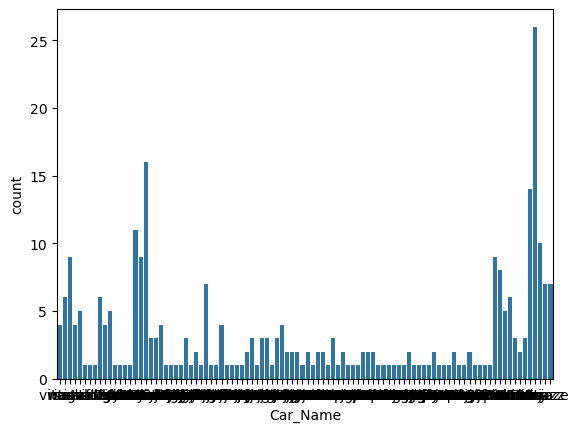

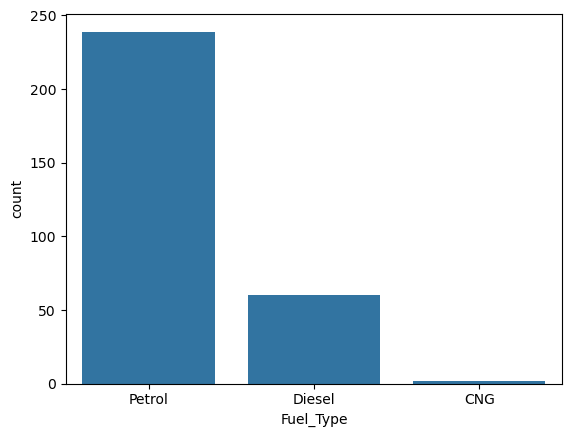

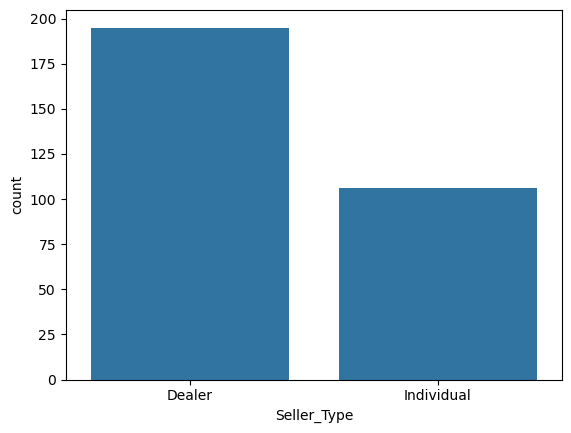

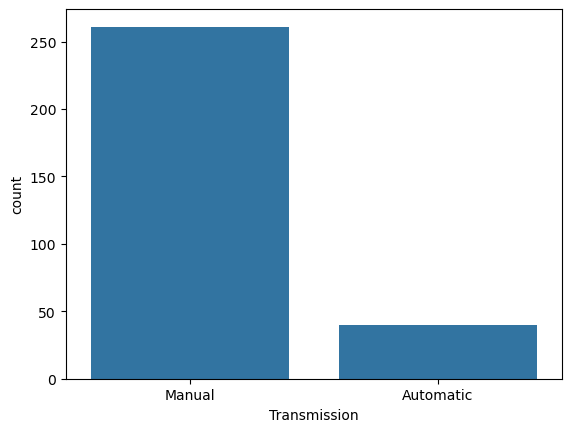

In [16]:
for col in df:
    if df[col].dtype == 'O':  
        plt.show()

In [17]:
#These visualizations help us identify which categories are more prevalent, assess potential class imbalances, and evaluate whether the data is logically consistent. For example, if the 'fuel_type' variable contains only a single category , this could indicate an issue with the dataset.
#In summary, these plots provide a graphical overview of the distribution of all categorical features.


In [18]:
df  

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [20]:
!pip install wordcloud

In [22]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


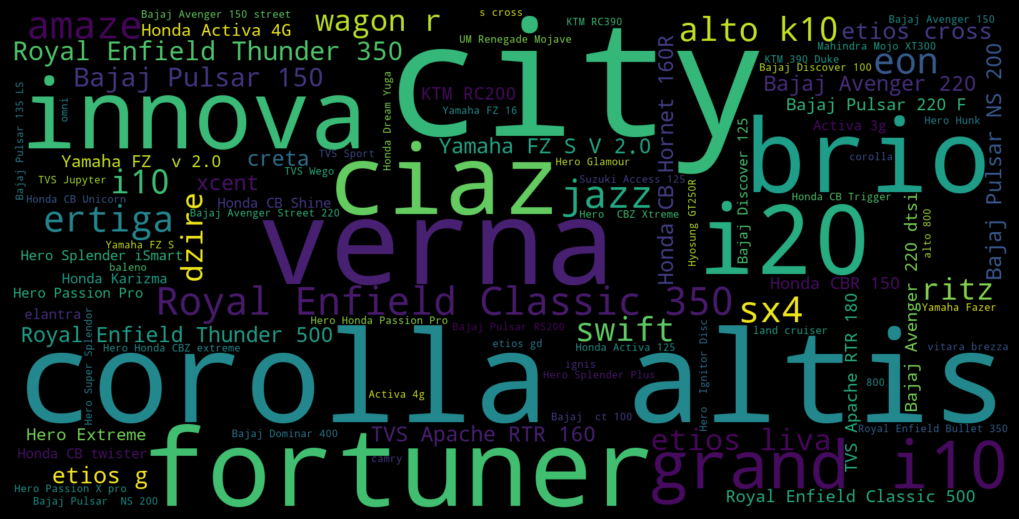

In [24]:

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import pandas as pd


stop_words_list = set(STOPWORDS)


counts = Counter(df["Car_Name"].dropna().apply(lambda x: str(x))) #neye göre sıklığına bakacaksam o sütunun ismni yazıyorum

# Generate the word cloud
wcc = WordCloud(
    background_color="black",
    width=1600, height=800,
    max_words=2000,
    stopwords=stop_words_list
)
wcc.generate_from_frequencies(counts)

# Display the word cloud
plt.figure(figsize=(10, 5), facecolor='k')
plt.imshow(wcc, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

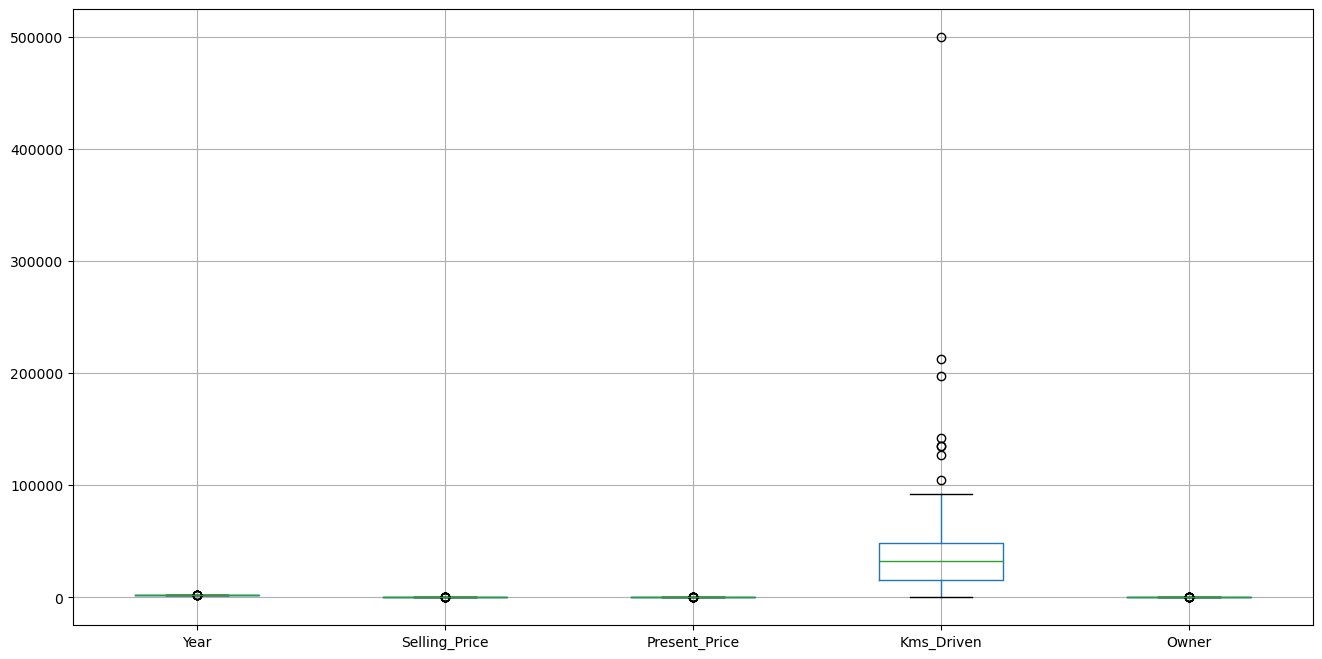

In [28]:
#Visualize boxplot to identify outliers
df.boxplot(figsize=(16,8))  #df bizim veri tablomun adı 
plt.show()

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


car_data = df.copy()


car_data["Brand"] = car_data["Car_Name"].str.split().str[0]


car_data = car_data.drop("Car_Name", axis=1)


X = car_data.drop("Selling_Price", axis=1)
y = car_data["Selling_Price"]


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error'  
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_train = best_rf.predict(X_train)
y_pred = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Train MAE: 0.2714233983796668
Test MAE: 0.586690171306979
RMSE: 0.8701182589259084
R2: 0.9671332071539414


In [32]:
#The Random Forest Regressor model was optimized using GridSearchCV.
#The best hyperparameters were found to be **max_depth = 10**, **min_samples_split = 2**, and **n_estimators = 100**.

#On the test set, the model achieved **MAE = 0.587**, **RMSE = 0.870**, and **R² = 0.967**.
#These results indicate that the model is capable of predicting car prices with high accuracy.


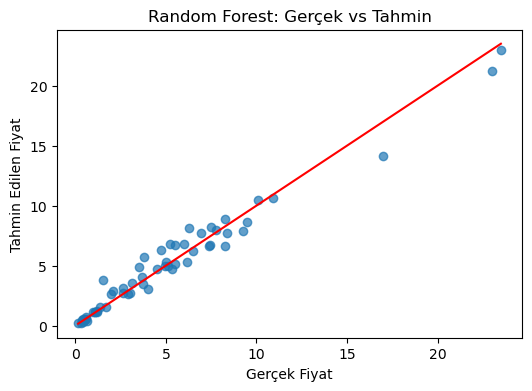

In [33]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.7)


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Real Price")
plt.ylabel("Estimated Price")
plt.title("Random Forest: Real vs. Prediction")

plt.show()

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


model = LinearRegression()


param_grid = {
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


best_lr = grid_search.best_estimator_


y_pred_train = best_lr.predict(X_train)
y_pred = best_lr.predict(X_test)


print("\nTrain MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Best parameters: {'fit_intercept': True}

Train MAE: 0.7937287918772168
Test MAE: 1.2184085862601628
RMSE: 1.85972758520634
R2: 0.8498589567748539


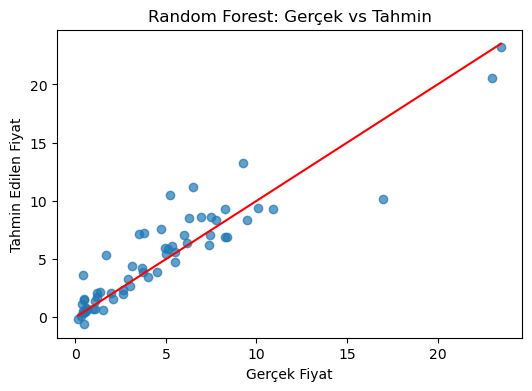

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))


plt.scatter(y_test, y_pred, alpha=0.7)


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')


plt.xlabel("Real Price")
plt.ylabel("Estimated Price")
plt.title("Random Forest: Real vs. Prediction")

plt.show()

In [37]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Multi Layer Perceptron Regressor
param_grid_mlp = {
    'hidden_layer_sizes': [(100,), (100, 50)],
    'alpha': [0.0001, 0.001],
}

# Grid search with 3-fold cross validation
grid_mlp = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid_mlp,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid_mlp.fit(X_train, y_train)
print('Best MLP parameters:', grid_mlp.best_params_)

# Get the best model and make predictions
best_mlp = grid_mlp.best_estimator_
y_pred_train_mlp = best_mlp.predict(X_train)
y_pred_mlp = best_mlp.predict(X_test)

# Evaluate the model
train_mae = mean_absolute_error(y_train, y_pred_train_mlp)
test_mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print(f'\nTrain MAE: {train_mae:.4f}\n')
print(f'Test MAE: {test_mae:.4f}\n')
print(f'RMSE: {rmse:.4f}\n')
print(f'R2: {r2:.4f}\n')

Best MLP parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}

Train MAE: 0.1811

Test MAE: 0.5829

RMSE: 0.9139

R2: 0.9637



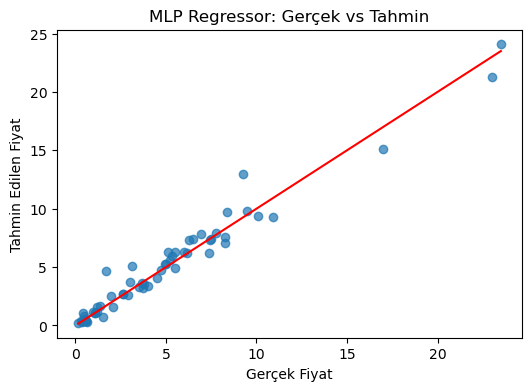

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_mlp, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Real Price")
plt.ylabel("Estimated Price")
plt.title("MLP Regressor: Real vs. Prediction")
plt.show()

In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_rf = best_rf.predict(X_test)
y_pred_lr = best_lr.predict(X_test)
y_pred_mlp = best_mlp.predict(X_test)


results = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression", "MLP Regressor"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_mlp)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_mlp)
    ]
})

print(results)

               Model       MAE      RMSE        R2
0      Random Forest  0.586690  0.870118  0.967133
1  Linear Regression  1.218409  1.859728  0.849859
2      MLP Regressor  0.582944  0.913949  0.963739


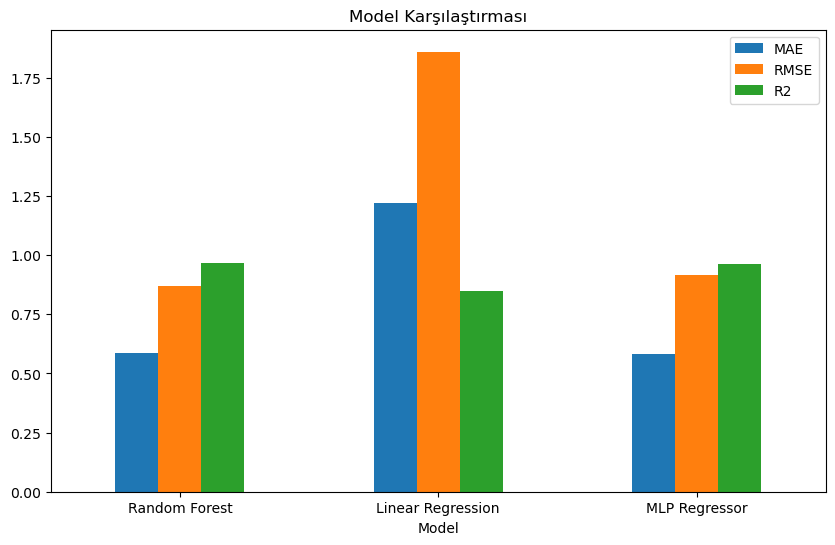

In [40]:
import matplotlib.pyplot as plt

results.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

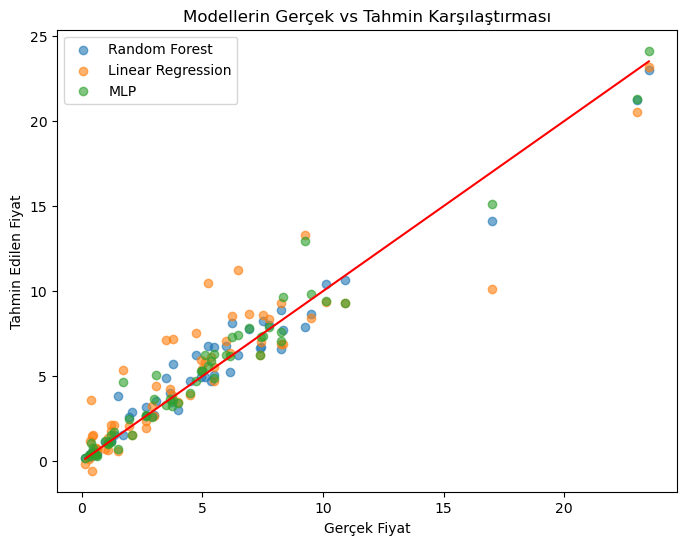

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest")
plt.scatter(y_test, y_pred_lr, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_mlp, alpha=0.6, label="MLP")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Real Price")
plt.ylabel("Estimated Price")
plt.title("Comparison of Actual vs. Predicted Models")
plt.legend()
plt.show()